In [2]:
import os
os.chdir('..')  # move up to repo root

import wfdb
import numpy as np
import matplotlib.pyplot as plt

record = wfdb.rdrecord('data/raw/100')
annotation = wfdb.rdann('data/raw/100', 'atr')

print("Signal shape:", record.p_signal.shape)
print("Sampling frequency:", record.fs, "Hz")
print("Signal names:", record.sig_name)
print("Duration:", record.p_signal.shape[0] / record.fs, "seconds")

Signal shape: (650000, 2)
Sampling frequency: 360 Hz
Signal names: ['MLII', 'V5']
Duration: 1805.5555555555557 seconds


In [3]:
print("Total annotations:", len(annotation.sample))
print("First 10 R-peak positions (samples):", annotation.sample[:10])
print("First 10 beat symbols:", annotation.symbol[:10])
print("\nUnique symbols in this record:", set(annotation.symbol))

Total annotations: 2274
First 10 R-peak positions (samples): [  18   77  370  662  946 1231 1515 1809 2044 2402]
First 10 beat symbols: ['+', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'A', 'N']

Unique symbols in this record: {'V', '+', 'A', 'N'}


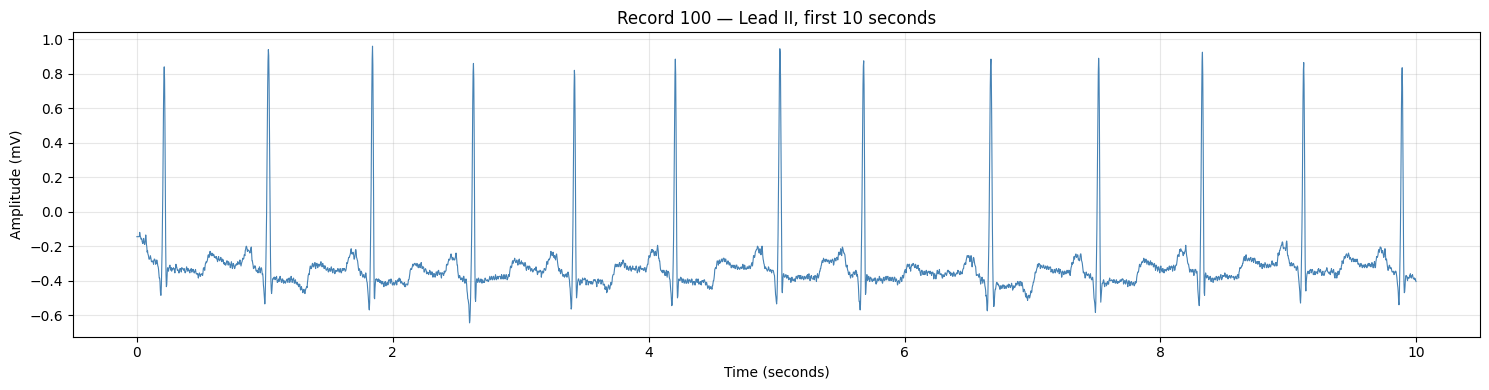

In [4]:
import matplotlib.pyplot as plt

signal = record.p_signal[:, 0]  # Lead II only
fs = record.fs

# Plot first 10 seconds
duration_samples = 10 * fs
t = np.arange(duration_samples) / fs

plt.figure(figsize=(15, 4))
plt.plot(t, signal[:duration_samples], color='steelblue', linewidth=0.8)
plt.xlabel('Time (seconds)')
plt.ylabel('Amplitude (mV)')
plt.title('Record 100 — Lead II, first 10 seconds')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('results/figures/raw_ecg.png', dpi=150)
plt.show()

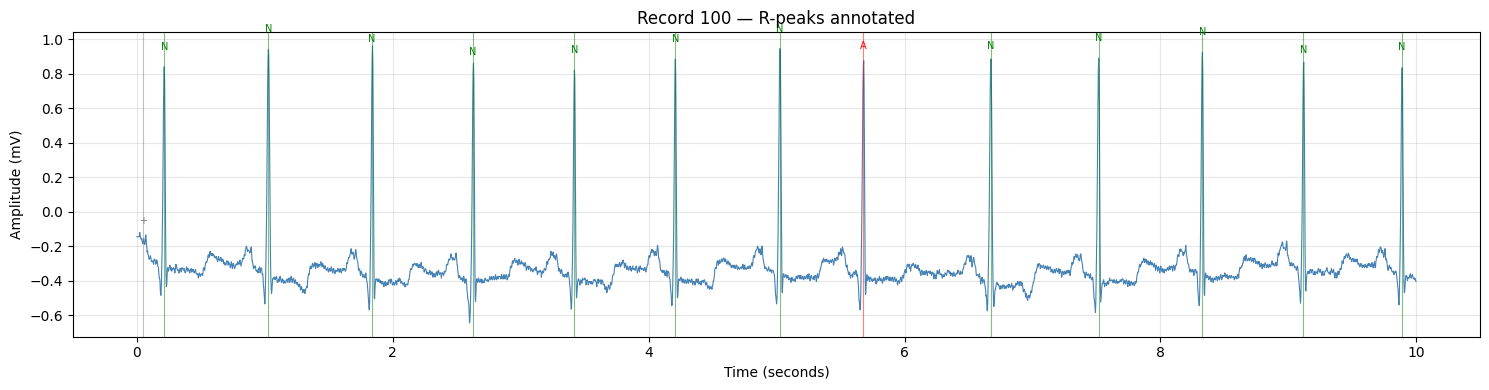

In [5]:
# Plot first 10 seconds with R-peaks marked
duration_samples = 10 * fs
t = np.arange(duration_samples) / fs

# Filter annotations to first 10 seconds
mask = annotation.sample < duration_samples
r_peaks = annotation.sample[mask]
symbols = np.array(annotation.symbol)[mask]

plt.figure(figsize=(15, 4))
plt.plot(t, signal[:duration_samples], color='steelblue', linewidth=0.8)

# Mark each R-peak and label it
colors = {'N': 'green', 'A': 'red', 'V': 'orange', '+': 'gray'}
for peak, sym in zip(r_peaks, symbols):
    color = colors.get(sym, 'black')
    plt.axvline(x=peak/fs, color=color, alpha=0.5, linewidth=0.8)
    plt.text(peak/fs, signal[peak] + 0.1, sym, fontsize=7, color=color, ha='center')

plt.xlabel('Time (seconds)')
plt.ylabel('Amplitude (mV)')
plt.title('Record 100 — R-peaks annotated')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('results/figures/rpeak_annotated.png', dpi=150)
plt.show()